In [17]:
import math
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [18]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 64          # resize pet images to 64x64 (keeps training fast)
BATCH_SIZE = 32
EPOCHS = 10             # bump this up for better results
LR = 2e-4
T = 1000                # number of diffusion timesteps
BASE_CH = 64            # base channel count for the U-Net
DATA_ROOT = "./data"
OUT_DIR = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

torch.manual_seed(0)

In [19]:
def normalize(x):
    return x * 2 - 1

In [20]:
def get_dataloader(batch_size=BATCH_SIZE, img_size=IMG_SIZE):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),                       # -> [0, 1]
        transforms.Lambda(normalize),   # -> [-1, 1]
    ])

    dataset = datasets.OxfordIIITPet(
        root=DATA_ROOT,
        split="trainval",
        target_types="category",
        download=True,
        transform=transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True,
    )
    return loader

In [21]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        freq = math.log(10000) / (half_dim - 1)
        freq = torch.exp(torch.arange(half_dim, device=device) * -freq)
        args = t[:, None].float() * freq[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:  # zero-pad if odd
            emb = F.pad(emb, (0, 1))
        return emb

In [22]:
class TimeMLP(nn.Module):
    def __init__(self, dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            SinusoidalTimeEmbedding(dim),
            nn.Linear(dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, t):
        return self.net(t)

In [23]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]   # inject time info
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [24]:
class Down(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.block = ResBlock(in_ch, out_ch, time_dim)
        self.pool = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t_emb):
        h = self.block(x, t_emb)
        down = self.pool(h)
        return down, h 

In [25]:
class Up(nn.Module):
    def __init__(self, in_ch, out_ch, skip_ch, time_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1)
        # after concatenating with the skip connection, channels = out_ch + skip_ch
        self.block = ResBlock(out_ch + skip_ch, out_ch, time_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.block(x, t_emb)

In [26]:
class SimpleUNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=BASE_CH, time_dim=256):
        super().__init__()
        self.time_mlp = TimeMLP(time_dim, time_dim)

        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        self.down1 = Down(base_ch, base_ch, time_dim)          # 64 -> 64
        self.down2 = Down(base_ch, base_ch * 2, time_dim)      # 64 -> 128
        self.down3 = Down(base_ch * 2, base_ch * 4, time_dim)  # 128 -> 256

        self.bottleneck1 = ResBlock(base_ch * 4, base_ch * 4, time_dim)
        self.bottleneck2 = ResBlock(base_ch * 4, base_ch * 4, time_dim)

        self.up3 = Up(base_ch * 4, base_ch * 2, base_ch * 4, time_dim)  # 256 -> 128, skip=256
        self.up2 = Up(base_ch * 2, base_ch, base_ch * 2, time_dim)      # 128 -> 64,  skip=128
        self.up1 = Up(base_ch, base_ch, base_ch, time_dim)              # 64  -> 64,  skip=64

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        h = self.in_conv(x)

        d1, skip1 = self.down1(h, t_emb)
        d2, skip2 = self.down2(d1, t_emb)
        d3, skip3 = self.down3(d2, t_emb)

        b = self.bottleneck1(d3, t_emb)
        b = self.bottleneck2(b, t_emb)

        u3 = self.up3(b, skip3, t_emb)
        u2 = self.up2(u3, skip2, t_emb)
        u1 = self.up1(u2, skip1, t_emb)

        out = self.out_conv(F.silu(self.out_norm(u1)))
        return out

In [27]:
class Diffusion:
    def __init__(self, timesteps=T, beta_start=1e-4, beta_end=0.02, device=DEVICE):
        self.T = timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        """Forward diffusion: sample x_t given x_0 and timestep t."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_1m_ac = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_1m_ac * noise, noise

In [28]:
def train(model, diffusion, dataloader, epochs=EPOCHS, lr=LR, device=DEVICE):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        n_batches = 0
        for images, _ in dataloader:
            images = images.to(device)
            batch_size = images.size(0)

            # sample random timesteps for each image in the batch
            t = torch.randint(0, diffusion.T, (batch_size,), device=device).long()

            # forward diffusion: add noise according to t
            x_t, noise = diffusion.q_sample(images, t)

            # predict the noise
            predicted_noise = model(x_t, t)

            loss = F.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f"Epoch [{epoch + 1}/{epochs}]  MSE Loss: {avg_loss:.4f}")

    return losses

In [29]:
def plot_loss(losses, out_path=os.path.join(OUT_DIR, "training_loss.png")):
    plt.figure(figsize=(7, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss vs. Epoch")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f"Saved loss curve to {out_path}")

In [30]:
def visualize_noise_predictions(model, diffusion, dataloader, device=DEVICE,
                                 n_samples=4,
                                 out_path=os.path.join(OUT_DIR, "noise_predictions.png")):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images[:n_samples].to(device)

    t = torch.randint(0, diffusion.T, (n_samples,), device=device).long()
    x_t, noise = diffusion.q_sample(images, t)

    with torch.no_grad():
        predicted_noise = model(x_t, t)

    def to_show(img_tensor):
        # noise / images are roughly in [-1, 1]; rescale to [0, 1] for display
        img = img_tensor.detach().cpu()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img.permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(3, n_samples, figsize=(3 * n_samples, 9))
    for i in range(n_samples):
        axes[0, i].imshow((images[i].cpu().permute(1, 2, 0).numpy() + 1) / 2)
        axes[0, i].set_title(f"Original (t={t[i].item()})")
        axes[0, i].axis("off")

        axes[1, i].imshow(to_show(noise[i]))
        axes[1, i].set_title("Actual Noise")
        axes[1, i].axis("off")

        axes[2, i].imshow(to_show(predicted_noise[i]))
        axes[2, i].set_title("Predicted Noise")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f"Saved noise visualization to {out_path}")

In [31]:
dataloader = get_dataloader()

In [32]:
model = SimpleUNet().to(DEVICE)
diffusion = Diffusion()

Epoch [1/10]  MSE Loss: 0.1609
Epoch [2/10]  MSE Loss: 0.0621
Epoch [3/10]  MSE Loss: 0.0495
Epoch [4/10]  MSE Loss: 0.0442
Epoch [5/10]  MSE Loss: 0.0407
Epoch [6/10]  MSE Loss: 0.0365
Epoch [7/10]  MSE Loss: 0.0402
Epoch [8/10]  MSE Loss: 0.0333
Epoch [9/10]  MSE Loss: 0.0348
Epoch [10/10]  MSE Loss: 0.0336


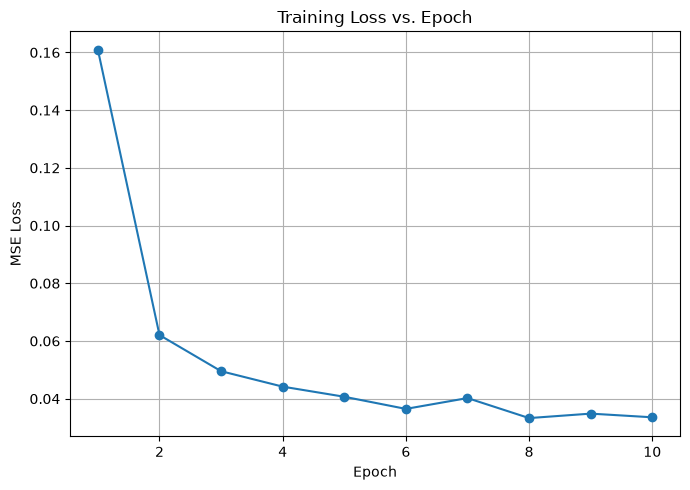

Saved loss curve to ./outputs\training_loss.png


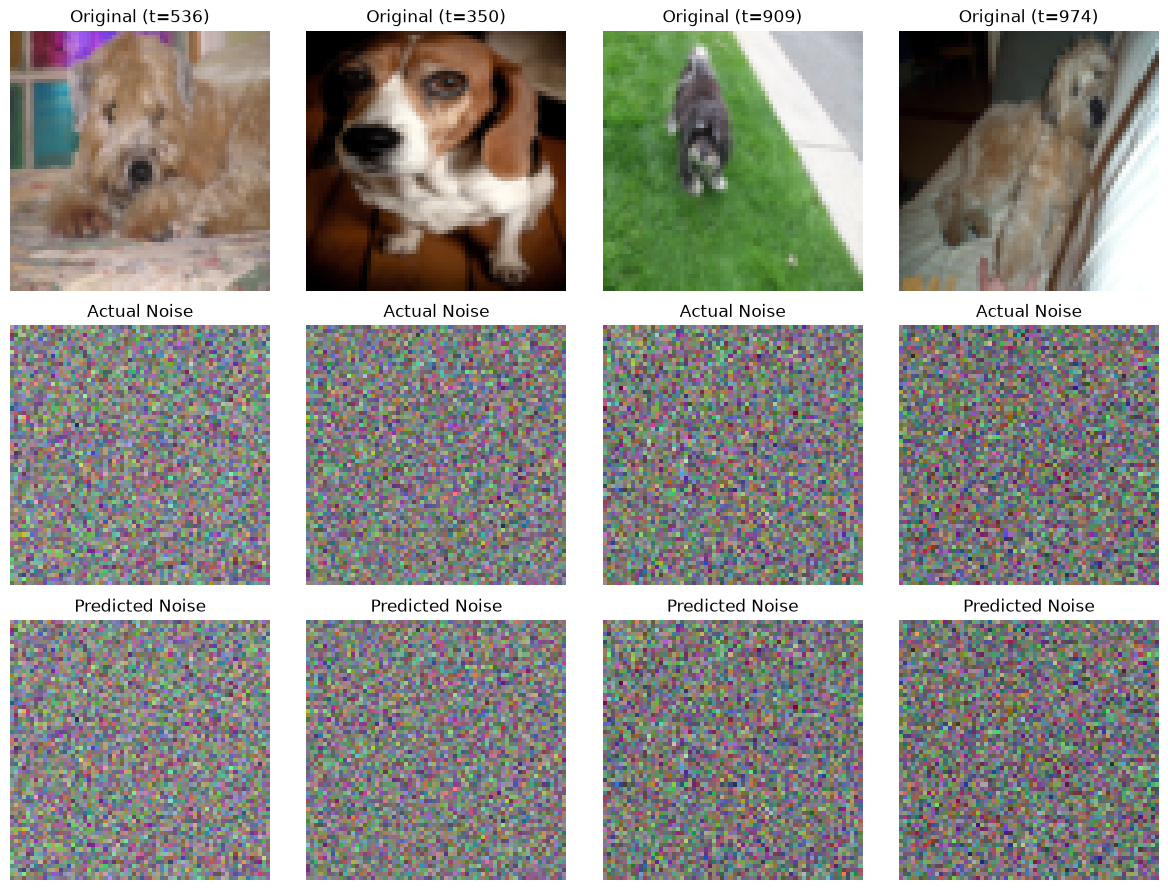

Saved noise visualization to ./outputs\noise_predictions.png


In [33]:
losses = train(model, diffusion, dataloader)
plot_loss(losses)
visualize_noise_predictions(model, diffusion, dataloader)

In [34]:
torch.save(model.state_dict(), os.path.join(OUT_DIR, "unet_diffusion_pets.pt"))